# Notes

Currently time series work even with duplicate measurement, but they are all on different graphs. Leaving that for now. Need to do soil profiles and check soil moisture and snow depth across sites.

In [49]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import pandas as pd
import os
import matplotlib.cm as cm
from io import StringIO
import sys
import nc_time_axis
import os

sys.path.append('C:/Users/madel/Code/GeoNorth')

from utils import *

In [134]:
site = "TVC"
vari = "TSOI"
ctsm_file = f"..\\CTSM_data\\run_1\\merged_files\\{site}_1995-2014.nc"
df = xr.open_dataset(ctsm_file, engine="netcdf4")
ds_ctsm = df[f"{vari}"]
ds = xr.open_dataset(f"../Observational_data/{site}_obs/processed/{site}_{vari}.nc")
ds_obs = ds[f"{vari}"]
ds_obs = ds_obs.sortby("depth")

C:\Users\madel\AppData\Local\Temp\ipykernel_32088\727719220.py:4: FutureWarning: In a future version, xarray will not decode the variable 'SNOW_PERSISTENCE' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  df = xr.open_dataset(ctsm_file, engine="netcdf4")


In [135]:
ds_ctsm

<xarray.DataArray 'TSOI' (time: 7300, levgrnd: 25, lndgrid: 1)> Size: 730kB
[182500 values with dtype=float32]
Coordinates:
  * time     (time) object 58kB 1995-01-01 00:00:00 ... 2014-12-31 00:00:00
  * levgrnd  (levgrnd) float32 100B 0.01 0.04 0.09 0.16 ... 19.48 28.87 42.0
Dimensions without coordinates: lndgrid
Attributes:
    long_name:      soil temperature (natural vegetated and crop landunits only)
    units:          K
    cell_methods:   time: mean
    landunit_mask:  veg

In [136]:
ds_obs

<xarray.DataArray 'TSOI' (time: 350353, depth: 16)> Size: 45MB
[5605648 values with dtype=float64]
Coordinates:
  * time     (time) object 3MB 1995-01-01 00:00:00 ... 2014-12-31 00:00:00
  * depth    (depth) float64 128B 0.05 0.1 0.101 0.102 ... 0.9 1.04 1.16 1.17
Attributes:
    units:    °C

In [139]:
def rmse_from_means(obs_mean, sim_mean):
    """RMSE between two equal-length lists of monthly means, skipping NaNs."""
    o = np.array(obs_mean, dtype=float)
    s = np.array(sim_mean, dtype=float)
    mask = ~(np.isnan(o) | np.isnan(s))
    if not mask.any():
        return np.nan
    return float(np.sqrt(np.mean((o[mask] - s[mask]) ** 2)))

# Testing w/ Soil Moisture

In [119]:
site = "TVC" # testing with HC cause it has soil moisture dupes
vari = "H2OSOI"
ctsm_file = f"..\\CTSM_data\\run_1\\merged_files\\{site}_1995-2014.nc"
df = xr.open_dataset(ctsm_file, engine="netcdf4")
ds_ctsm = df[f"{vari}"]
ds = xr.open_dataset(f"../Observational_data/{site}_obs/processed/{site}_{vari}.nc")
ds_obs = ds[f"{vari}"]
ds_obs = ds_obs.sortby("depth")


C:\Users\madel\AppData\Local\Temp\ipykernel_32088\3557425090.py:4: FutureWarning: In a future version, xarray will not decode the variable 'SNOW_PERSISTENCE' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  df = xr.open_dataset(ctsm_file, engine="netcdf4")


In [120]:
print(ds_ctsm["time"].values[:6])
print(ds_ctsm["time"].dt.day.values[:6])   # if these are mostly 1, that's the tell

[cftime.DatetimeNoLeap(1995, 1, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1995, 1, 2, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1995, 1, 3, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1995, 1, 4, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1995, 1, 5, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1995, 1, 6, 0, 0, 0, 0, has_year_zero=True)]
[1 2 3 4 5 6]


In [121]:
ds_obs

<xarray.DataArray 'H2OSOI' (time: 350353, depth: 2)> Size: 6MB
[700706 values with dtype=float64]
Coordinates:
  * time     (time) object 3MB 1995-01-01 00:00:00 ... 2014-12-31 00:00:00
  * depth    (depth) float64 16B 0.08 0.15
Attributes:
    units:    mm3/mm3

In [122]:
print(ds_obs.depth)

<xarray.DataArray 'depth' (depth: 2)> Size: 16B
array([0.08, 0.15])
Coordinates:
  * depth    (depth) float64 16B 0.08 0.15


In [123]:
ds_ctsm

<xarray.DataArray 'H2OSOI' (time: 7300, levsoi: 20, lndgrid: 1)> Size: 584kB
[146000 values with dtype=float32]
Coordinates:
  * time     (time) object 58kB 1995-01-01 00:00:00 ... 2014-12-31 00:00:00
  * levsoi   (levsoi) float32 80B 0.01 0.04 0.09 0.16 ... 5.06 5.95 6.94 8.03
Dimensions without coordinates: lndgrid
Attributes:
    long_name:      volumetric soil water (natural vegetated and crop landuni...
    units:          mm3/mm3
    cell_methods:   time: mean
    landunit_mask:  veg

In [124]:
def compute_rmse_h2osoi(obs, sim, depths, vari):
    """
    Compute RMSE, bias, correlation, and unbiased RMSE between observed and
    simulated values for the full year and for each season (water-year
    grouped), at each requested depth.

    Returns a pandas DataFrame with columns:
    depth_cm, sim_depth_cm, period, rmse, bias, corr, ubrmse, n
    """
    obs_daily = obs.resample(time="1D").mean()
    sim = sim.squeeze()  # drop any leftover size-1 dims like lndgrid

    season_months = {
        "Fall":   [9, 10, 11],
        "Winter": [12, 1, 2],
        "Spring": [3, 4, 5],
        "Summer": [6, 7, 8],
    }

    def compute_stats(o, s):
        if len(o) < 2:
            return {"rmse": np.nan, "bias": np.nan, "corr": np.nan, "ubrmse": np.nan}

        o_vals, s_vals = o.values, s.values
        bias = float(np.mean(s_vals - o_vals))
        rmse = float(np.sqrt(np.mean((o_vals - s_vals) ** 2)))
        # unbiased RMSE: RMSE after removing each series' own mean
        ubrmse = float(np.sqrt(np.mean(((s_vals - s_vals.mean()) - (o_vals - o_vals.mean())) ** 2)))
        # correlation undefined if either series is constant
        if np.std(o_vals) == 0 or np.std(s_vals) == 0:
            corr = np.nan
        else:
            corr = float(np.corrcoef(o_vals, s_vals)[0, 1])

        return {"rmse": rmse, "bias": bias, "corr": corr, "ubrmse": ubrmse}

    results = []

    for depth_x in depths:
        act_val = round(float(depth_x.values), 2)

        obs_sel = obs_daily.sel(depth=depth_x.values, method="nearest")
        sim_sel = sim.sel(levsoi=act_val, method="nearest")
        sim_depth = float(sim_sel.levsoi.values)

        obs_keys = pd.MultiIndex.from_arrays([
            obs_sel["time"].dt.year.values,
            obs_sel["time"].dt.month.values,
            obs_sel["time"].dt.day.values,
        ])
        sim_keys = pd.MultiIndex.from_arrays([
            sim_sel["time"].dt.year.values,
            sim_sel["time"].dt.month.values,
            sim_sel["time"].dt.day.values,
        ])

        obs_series = pd.Series(obs_sel.values, index=obs_keys)
        sim_series = pd.Series(sim_sel.values, index=sim_keys)

        common = obs_series.index.intersection(sim_series.index)
        obs_matched = obs_series.loc[common]
        sim_matched = sim_series.loc[common]

        mask = ~(obs_matched.isna() | sim_matched.isna())
        obs_matched = obs_matched[mask]
        sim_matched = sim_matched[mask]

        # Full year
        stats = compute_stats(obs_matched, sim_matched)
        results.append({
            "depth_cm": act_val * 100,
            "sim_depth_cm": sim_depth * 100,
            "period": "Full Year",
            **stats,
            "n": len(obs_matched),
        })

        # Per season
        month_arr = obs_matched.index.get_level_values(1)
        for season, months in season_months.items():
            smask = month_arr.isin(months)
            stats = compute_stats(obs_matched[smask], sim_matched[smask])
            results.append({
                "depth_cm": act_val * 100,
                "sim_depth_cm": sim_depth * 100,
                "period": season,
                **stats,
                "n": int(smask.sum()),
            })

    return pd.DataFrame(results)

In [125]:
import cftime

In [126]:
def final_plot_h2osoi(obs, sim, site, depths, vari, show=0):
    # Resample observational data to daily frequency
    obs_daily = obs.resample(time="1D").mean()

    year = 2006
    # Restrict both datasets to the requested year
    #obs_daily = obs_daily.sel(time=slice(f"{year}-01-01", f"{year}-12-31"))
    #sim = sim.sel(time=slice(f"{year}-01-01", f"{year}-12-31"))

    # Same palette as seasonal_plot_h2osoi_full
    season_colors = {"Fall": "goldenrod", "Winter": "steelblue", "Spring": "mediumseagreen", "Summer": "indianred"}

    # Meteorological season boundaries spanning the plotted year (Dec of prior
    # year -> Mar counts as Winter, so the year opens and closes in Winter)
    season_bounds = [
        (cftime.DatetimeNoLeap(year, 1, 1, 0, 0, 0, 0, has_year_zero=True),
         cftime.DatetimeNoLeap(year, 3, 1, 0, 0, 0, 0, has_year_zero=True), "Winter"),
        (cftime.DatetimeNoLeap(year, 3, 1, 0, 0, 0, 0, has_year_zero=True),
         cftime.DatetimeNoLeap(year, 6, 1, 0, 0, 0, 0, has_year_zero=True), "Spring"),
        (cftime.DatetimeNoLeap(year, 6, 1, 0, 0, 0, 0, has_year_zero=True),
         cftime.DatetimeNoLeap(year, 9, 1, 0, 0, 0, 0, has_year_zero=True), "Summer"),
        (cftime.DatetimeNoLeap(year, 9, 1, 0, 0, 0, 0, has_year_zero=True),
         cftime.DatetimeNoLeap(year, 12, 1, 0, 0, 0, 0, has_year_zero=True), "Fall"),
        (cftime.DatetimeNoLeap(year, 12, 1, 0, 0, 0, 0, has_year_zero=True),
         cftime.DatetimeNoLeap(year + 1, 1, 1, 0, 0, 0, 0, has_year_zero=True), "Winter"),
    ]

    for x in depths:

        plt.figure(figsize=(14, 6))

        # Shade background by season (Fall/Winter/Spring/Summer)
        for start, end, sname in season_bounds:
            plt.axvspan(start, end, color=season_colors[sname], alpha=0.08)

        # Observed (daily)
        act_val = round(float(x.values), 2)
        plt.plot(
            obs_daily["time"].values,
            obs_daily.sel(depth=x.values, method="nearest").values,
            label=f"Observed - {act_val*100:.0f}cm",
            linewidth=2
        )

        # Simulated
        sim_depth = sim.sel(levsoi=act_val, method="nearest").levsoi.values

        plt.plot(
            sim["time"].values,
            sim.sel(levsoi=act_val, method="nearest").values,
            label=f"Simulated - {sim_depth*100:.0f}cm",
            linewidth=2
        )

        # Labeling
        remain = int(round(x.values - act_val, 3) * 1000)

        plt.xlabel("Time")
        plt.ylabel(f"{vari}")
        plt.title(f"{vari} at {site}")
        plt.grid(True)
        plt.legend()
        plt.xlim(
            cftime.DatetimeNoLeap(year, 9, 1, 0, 0, 0, 0, has_year_zero=True),
            cftime.DatetimeNoLeap(year + 1, 8, 1, 0, 0, 0, 0, has_year_zero=True)
        )
        #plt.savefig(f"v1.0_final_images/{site}/{vari}/{site}_{vari}_{act_val*100:.0f}cm_{remain}.png")
        if not show:
            plt.close()

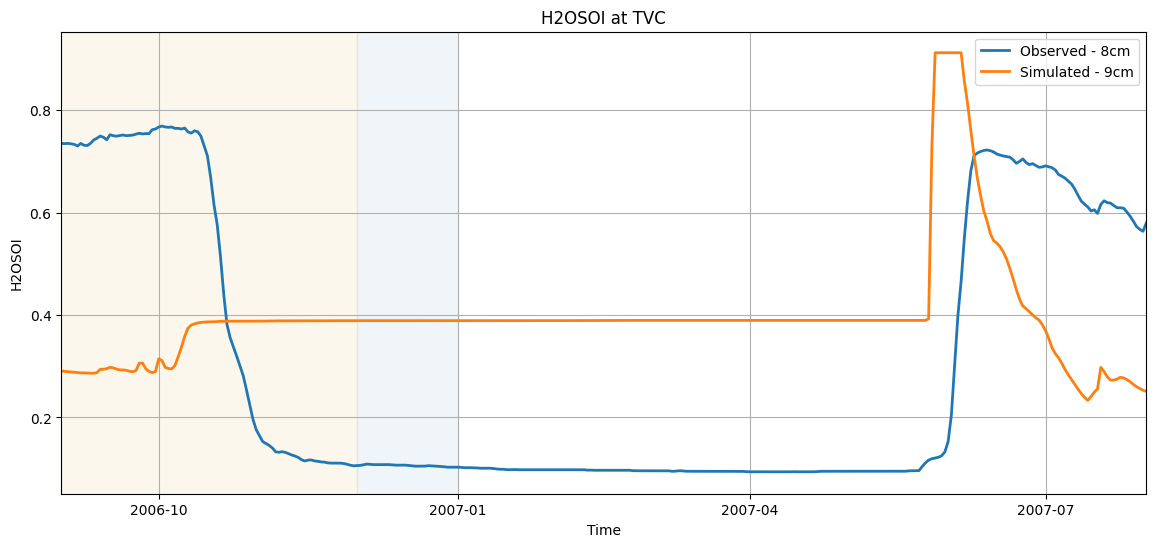

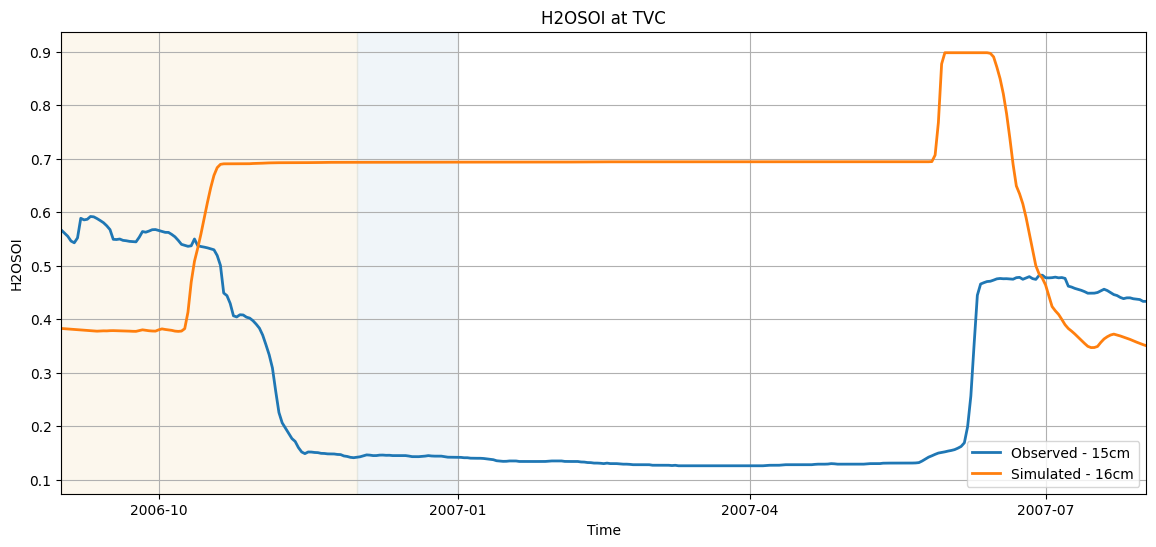

In [127]:
final_plot_h2osoi(ds_obs, ds_ctsm, f"{site}", ds_obs.depth, f"{vari}", show=1)

In [ ]:
def seasonal_plot_h2osoi_full(obs, sim, site, depths, vari, show=0):
    # Resample obs to daily
    obs_daily = obs.resample(time="1D").mean()

    liquid = sim["SOILLIQ"].sel(levsoi=act_val, method='nearest')
    delta = sim["DZSOI"].sel(levgrnd=act_val, method='nearest')

    sim_l = liquid/1000/delta

    # Water-year order: Sep -> Aug
    season = ["Fall", "Winter", "Spring", "Summer"]
    
    month_order = [ 9, 10, 11, 12, 1, 2, 3, 4, 5, 6, 7, 8]
    month_labels = ["S","O", "N", "D", "J", "F", "M", "A", "M", "J", "J", "A"]
    x = np.arange(len(month_order))

    for depth_x in depths:
        act_val = round(float(depth_x.values), 2)

        # Monthly means, one value per year per month
        obs_sel = obs_daily.sel(depth=depth_x.values, method="nearest")
        sim_sel = sim_l.sel(levsoi=act_val, method="nearest")
        sim_depth = sim_sel.levsoi.values

        obs_monthly = obs_sel.resample(time="1ME").mean(skipna=True)
        sim_monthly = sim_sel.resample(time="1ME").mean(skipna=True)

        obs_mean, obs_min, obs_max = [], [], []
        sim_mean, sim_min, sim_max = [], [], []

        
        for m in month_order:
            ov = obs_monthly.sel(time=obs_monthly["time"].dt.month == m).values
            sv = sim_monthly.sel(time=sim_monthly["time"].dt.month == m).values
            ov = ov[~np.isnan(ov)]
            sv = sv[~np.isnan(sv)]

            obs_mean.append(np.mean(ov) if len(ov) else np.nan)
            obs_min.append(np.min(ov) if len(ov) else np.nan)
            obs_max.append(np.max(ov) if len(ov) else np.nan)

            sim_mean.append(np.mean(sv) if len(sv) else np.nan)
            sim_min.append(np.min(sv) if len(sv) else np.nan)
            sim_max.append(np.max(sv) if len(sv) else np.nan)

        plt.figure(figsize=(8, 5))
        # Shade background by season (Fall/Winter/Spring/Summer, water-year order)
        season_colors = {"Fall": "goldenrod", "Winter": "steelblue", "Spring": "mediumseagreen", "Summer": "indianred"}
        season_bounds = [(-0.5, 2.5, "Fall"), (2.5, 5.5, "Winter"), (5.5, 8.5, "Spring"), (8.5, 11.5, "Summer")]
        for start, end, sname in season_bounds:
            plt.axvspan(start, end, color=season_colors[sname], alpha=0.08)
        plt.plot(x, obs_mean, "-", color="gray", label=f"Observed - {act_val*100:.0f}cm", linewidth=2)
        plt.fill_between(x, obs_min, obs_max, color="gray", alpha=0.3)

        plt.plot(x, sim_mean, "-", color="crimson", label=f"Simulated - {sim_depth*100:.0f}cm", linewidth=2)
        plt.fill_between(x, sim_min, sim_max, color="crimson", alpha=0.3)
        
        season_rmse = rmse_from_means(obs_mean, sim_mean)
        #print(season_rmse)

        plt.xticks(x, month_labels)
        plt.xlabel("Month")
        plt.ylabel("Volumetric Soil Water (mm3/mm3)")
        plt.title(f"Soil Moisture at TVC - {act_val*100:.0f}cm")
        plt.grid(True)
        plt.legend(loc='lower right')

        remain = int(round(depth_x.values - act_val, 3) * 1000)
        #plt.savefig(f"v1.0_final_images/{site}/{vari}/{site}_{vari}_{act_val*100:.0f}cm_{remain}_seasonal.png")
        if not show:
            plt.close()

0.3183821892116882
0.46016361148386736


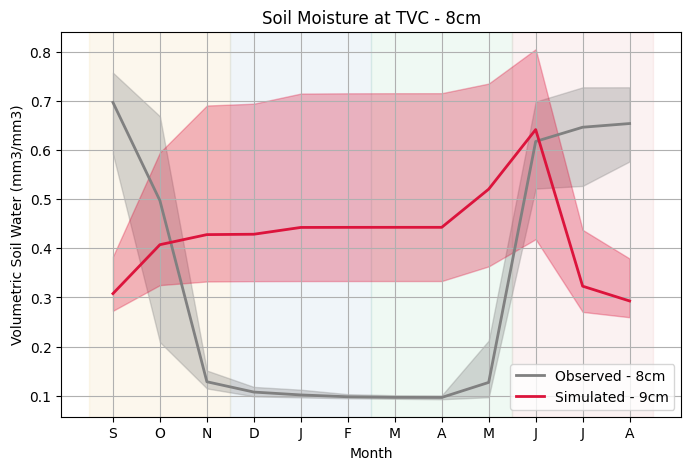

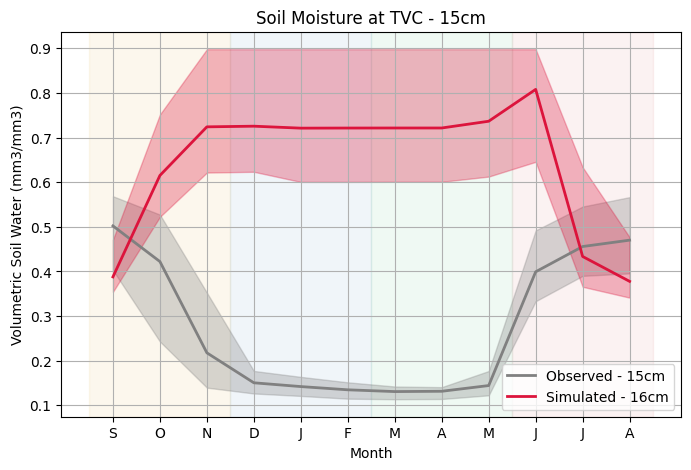

In [133]:
seasonal_plot_h2osoi_full(ds_obs, ds_ctsm, site, ds_obs.depth, vari, show=1)

In [78]:
def seasonal_plot_h2osoi_season(obs, sim, site, depths, vari, show=0):
    # Resample obs to daily
    obs_daily = obs.resample(time="1D").mean()

    # Water-year order: Sep -> Aug, grouped into seasons
    season_months = {
        "Fall":   [9, 10, 11],
        "Winter": [12, 1, 2],
        "Spring": [3, 4, 5],
        "Summer": [6, 7, 8],
    }
    month_label_map = {
        9: "S", 10: "O", 11: "N", 12: "D",
        1: "J", 2: "F", 3: "M", 4: "A",
        5: "M", 6: "J", 7: "J", 8: "A"
    }

    for depth_x in depths:
        act_val = round(float(depth_x.values), 2)

        obs_sel = obs_daily.sel(depth=depth_x.values, method="nearest")
        sim_sel = sim.sel(levsoi=act_val, method="nearest")
        sim_depth = sim_sel.levsoi.values

        obs_monthly = obs_sel.resample(time="1ME").mean(skipna=True)
        sim_monthly = sim_sel.resample(time="1ME").mean(skipna=True)

        remain = int(round(depth_x.values - act_val, 3) * 1000)

        for season, months in season_months.items():

            x = np.arange(len(months))
            month_labels = [month_label_map[m] for m in months]

            obs_mean, obs_min, obs_max = [], [], []
            sim_mean, sim_min, sim_max = [], [], []

            for m in months:
                ov = obs_monthly.sel(time=obs_monthly["time"].dt.month == m).values
                sv = sim_monthly.sel(time=sim_monthly["time"].dt.month == m).values
                ov = ov[~np.isnan(ov)]
                sv = sv[~np.isnan(sv)]

                obs_mean.append(np.mean(ov) if len(ov) else np.nan)
                obs_min.append(np.min(ov) if len(ov) else np.nan)
                obs_max.append(np.max(ov) if len(ov) else np.nan)

                sim_mean.append(np.mean(sv) if len(sv) else np.nan)
                sim_min.append(np.min(sv) if len(sv) else np.nan)
                sim_max.append(np.max(sv) if len(sv) else np.nan)

            plt.figure(figsize=(6, 5))
            plt.plot(x, obs_mean, "-", color="gray", label=f"Observed - {act_val*100:.0f}cm", linewidth=2)
            plt.fill_between(x, obs_min, obs_max, color="gray", alpha=0.3)

            plt.plot(x, sim_mean, "-", color="crimson", label=f"Simulated - {sim_depth*100:.0f}cm", linewidth=2)
            plt.fill_between(x, sim_min, sim_max, color="crimson", alpha=0.3)

            season_rmse = rmse_from_means(obs_mean, sim_mean)
            print(f"{act_val*100:.0f}cm", season_rmse,  season)

            plt.xticks(x, month_labels)
            plt.xlabel("Month")
            plt.ylabel(f"{vari}")
            plt.title(f"{season} Cycle of {vari} at {site} - {act_val*100:.0f}cm")
            plt.grid(True)
            plt.legend()

            #plt.savefig(f"v1.0_final_images/{site}/{vari}/{site}_{vari}_{act_val*100:.0f}cm_{remain}_{season}.png")
            if not show:
                plt.close()

8cm 0.28804918152243747 Fall
8cm 0.3356564089093873 Winter
8cm 0.3624260572594098 Spring
8cm 0.28014044840154007 Summer
15cm 0.3197641711581765 Fall
15cm 0.5802987345978404 Winter
15cm 0.5910203680865206 Spring
15cm 0.24228366703111842 Summer


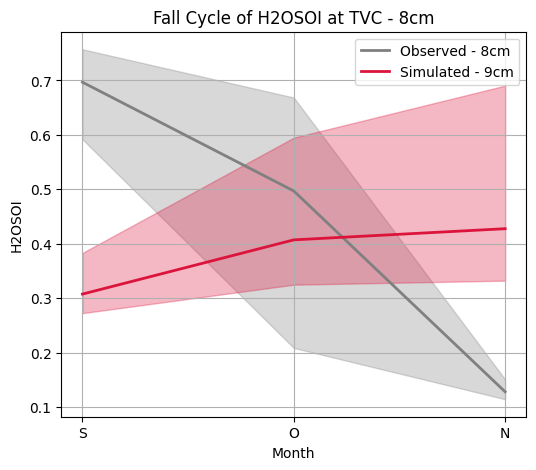

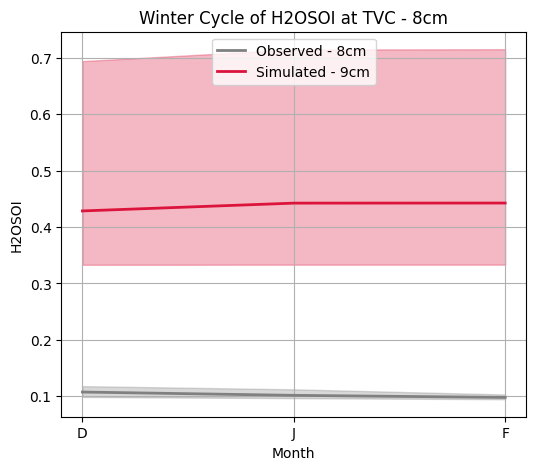

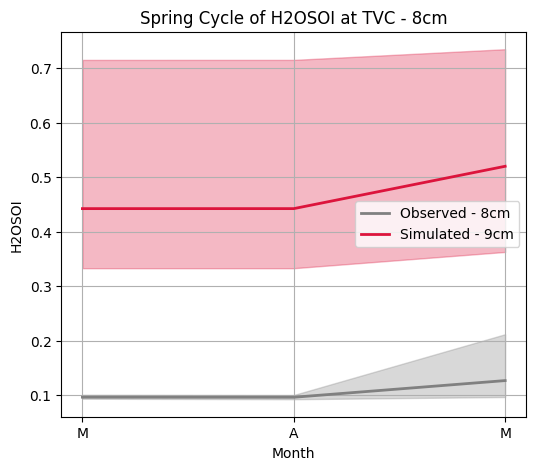

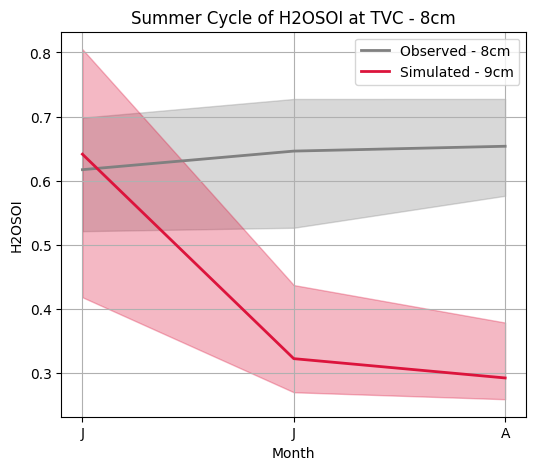

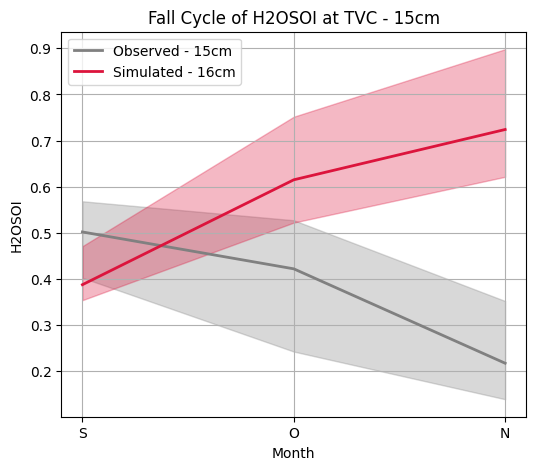

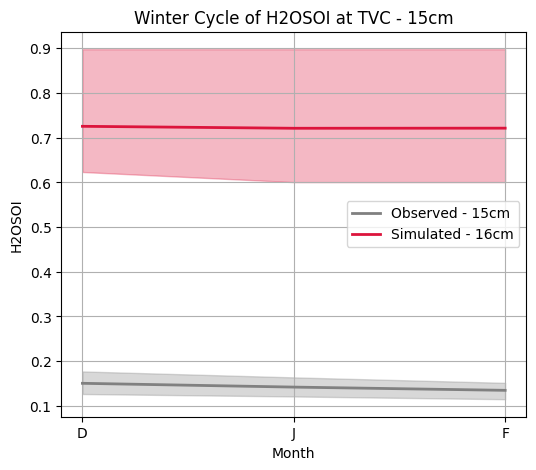

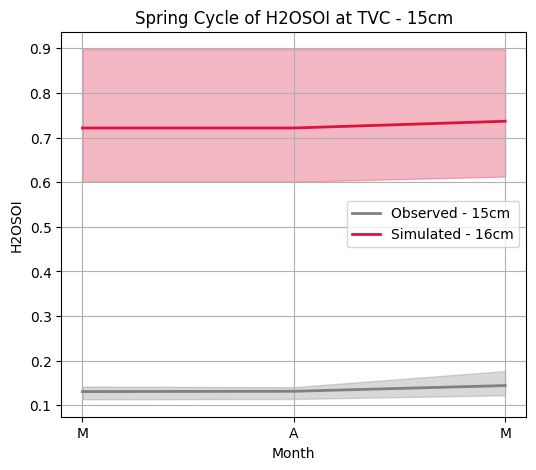

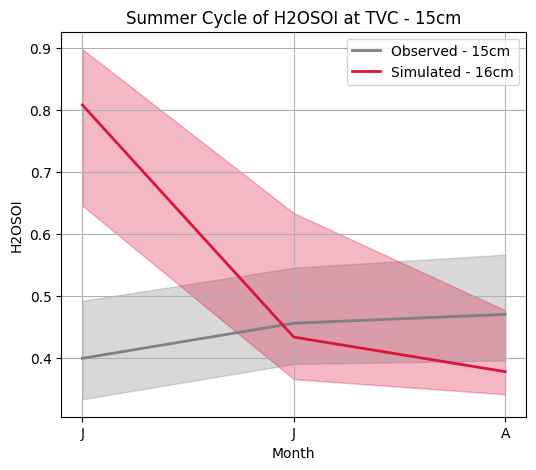

In [79]:
seasonal_plot_h2osoi_season(ds_obs, ds_ctsm, site, ds_obs.depth, vari, show=1)

In [82]:
def compute_rmse_h2osoi(obs, sim, depths, vari):
    """
    Compute RMSE, bias, correlation, and unbiased RMSE between observed and
    simulated values for the full year and for each season (water-year
    grouped), at each requested depth.

    Returns a pandas DataFrame with columns:
    depth_cm, sim_depth_cm, period, rmse, bias, corr, ubrmse, n
    """
    obs_daily = obs.resample(time="1D").mean()
    sim = sim.squeeze()  # drop any leftover size-1 dims like lndgrid

    season_months = {
        "Fall":   [9, 10, 11],
        "Winter": [12, 1, 2],
        "Spring": [3, 4, 5],
        "Summer": [6, 7, 8],
    }

    def compute_stats(o, s):
        if len(o) < 2:
            return {"rmse": np.nan, "bias": np.nan, "corr": np.nan, "ubrmse": np.nan}

        o_vals, s_vals = o.values, s.values
        bias = float(np.mean(s_vals - o_vals))
        rmse = float(np.sqrt(np.mean((o_vals - s_vals) ** 2)))
        # unbiased RMSE: RMSE after removing each series' own mean
        ubrmse = float(np.sqrt(np.mean(((s_vals - s_vals.mean()) - (o_vals - o_vals.mean())) ** 2)))
        # correlation undefined if either series is constant
        if np.std(o_vals) == 0 or np.std(s_vals) == 0:
            corr = np.nan
        else:
            corr = float(np.corrcoef(o_vals, s_vals)[0, 1])

        return {"rmse": rmse, "bias": bias, "corr": corr, "ubrmse": ubrmse}

    results = []

    for depth_x in depths:
        act_val = round(float(depth_x.values), 2)

        obs_sel = obs_daily.sel(depth=depth_x.values, method="nearest")
        sim_sel = sim.sel(levsoi=act_val, method="nearest")
        sim_depth = float(sim_sel.levsoi.values)

        obs_keys = pd.MultiIndex.from_arrays([
            obs_sel["time"].dt.year.values,
            obs_sel["time"].dt.month.values,
            obs_sel["time"].dt.day.values,
        ])
        sim_keys = pd.MultiIndex.from_arrays([
            sim_sel["time"].dt.year.values,
            sim_sel["time"].dt.month.values,
            sim_sel["time"].dt.day.values,
        ])

        obs_series = pd.Series(obs_sel.values, index=obs_keys)
        sim_series = pd.Series(sim_sel.values, index=sim_keys)

        common = obs_series.index.intersection(sim_series.index)
        obs_matched = obs_series.loc[common]
        sim_matched = sim_series.loc[common]

        mask = ~(obs_matched.isna() | sim_matched.isna())
        obs_matched = obs_matched[mask]
        sim_matched = sim_matched[mask]

        # Full year
        stats = compute_stats(obs_matched, sim_matched)
        results.append({
            "depth_cm": act_val * 100,
            "sim_depth_cm": sim_depth * 100,
            "period": "Full Year",
            **stats,
            "n": len(obs_matched),
        })

        # Per season
        month_arr = obs_matched.index.get_level_values(1)
        for season, months in season_months.items():
            smask = month_arr.isin(months)
            stats = compute_stats(obs_matched[smask], sim_matched[smask])
            results.append({
                "depth_cm": act_val * 100,
                "sim_depth_cm": sim_depth * 100,
                "period": season,
                **stats,
                "n": int(smask.sum()),
            })

    return pd.DataFrame(results)

In [83]:
rmse_df = compute_rmse_h2osoi(ds_obs, ds_ctsm, ds_obs.depth, vari)
rmse_df

,depth_cm,sim_depth_cm,period,rmse,bias,corr,ubrmse,n
0,8.0,9.0,Full Year,0.356836,0.131244,-0.227214,0.331824,3884
1,8.0,9.0,Fall,0.325242,-0.043980,-0.475414,0.322255,913
2,8.0,9.0,Winter,0.363908,0.353313,-0.048773,0.087169,1018
3,8.0,9.0,Spring,0.389405,0.372585,0.456498,0.113210,1028
4,8.0,9.0,Summer,0.340561,-0.208416,-0.316055,0.269341,925
5,15.0,16.0,Full Year,0.507657,0.402916,-0.646802,0.308827,3884
6,15.0,16.0,Fall,0.362218,0.210596,-0.639037,0.294706,913
7,15.0,16.0,Winter,0.620464,0.615772,0.144283,0.076162,1018
8,15.0,16.0,Spring,0.634016,0.629561,0.279047,0.075027,1028
9,15.0,16.0,Summer,0.286721,0.106604,-0.317186,0.266166,925
